In [1]:
:ls'''pip install psycopg2-binary
pip install sshtunnel'''

'pip install psycopg2-binary\npip install sshtunnel'

In [2]:
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
import statsmodels.api as sm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# dbname = 'ds_space'
# user = 'ds_team'
# password = 'ML2024'
# host = '83.166.239.235'
# port = '5432'

# with psycopg2.connect("host='{}' port={} dbname='{}' user={} password={}".format(host, port, dbname, user, password)) as conn:
#     sql = "select * from flat_data;"
#     df = pd.read_sql_query(sql, conn)

In [5]:
df = pd.read_csv('test_data_2024_09_15.csv')

/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3437: DtypeWarning: Columns (5,21,26,27,32,33,37,38,41,46,47) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
def unique_values(df):
    for column in df.columns:
        nunique_values = df[column].nunique()
        if df[column].isnull().sum() != 0:
            print(f'Признак: {column}')
            print(f'Кол-во пропущенных/всего: {df[column].isnull().sum()}/{len(df[column])}')
            print(f'Кол-во уникальных значений: {nunique_values}')
            print(f'Уникальные значения: \n{df[column].value_counts()}')
            print('\n')

In [7]:
# 1. Работаем только с одним городом
df = df[df['city'] != 'Москва']

In [8]:
# 2. Удаляем технические признаки
features_technical = [
    #'id_flat_adj',
                      'address_city_category_id',
                      'address_city_microcategory_id',
                      'address_city_verical',
                      'geo_around', #!!!
                      'source_name',
                      'doc_app_link',
                      'heat_index',
                      'id',
                      'source_id',
                      'parsed_at',
                      'updated_at']
df = df.drop(features_technical, axis=1)

In [9]:
# 3. Удаляем поля с большим кол-вом пропусков + неинформативные (некоторые можно будет добавить к тексту description)
features_meaningless = ['features_house',
                        'features_yard',
                        'parking_desc',
                        'height_m',
                        'summary_adj_seller',
                        'rooms_type',
                        'windows_type',
                        'furniture',
                        'technique',
                        'warm_floor',
                        'finishing_type',
                        'name_bd_house',
                        'name_bd_company',
                        'name_bd_seller',
                        'house_heat_type',
                        'emergency',
                        'entrances',
                        'garbage_chute',
                        'class_flat']
df = df.drop(features_meaningless, axis=1)

In [10]:
# 4. Рассматриваем только квартиры (без Апартаментов)
# unique_values(df[['status_flat']])

In [11]:
df = df[df['status_flat'] != 2]

# area_kitchen, area_live, area

In [12]:
import pandas as pd
import re

def clean_area_regex(value):
    value = re.sub(r'[^\d.,]', '', str(value))
    value = value.replace(',', '.')
    if value == '':
        return None
    else:
        return float(value)

df['area_kitchen'] = df['area_kitchen'].apply(clean_area_regex)
df['area'] = df['area'].apply(clean_area_regex)
df['area_live'] = df['area_live'].apply(clean_area_regex)

In [13]:
# Заполняем пропуски в area_kitchen
df['area_kitchen'] = df['area_kitchen'].fillna(df['area'] - df['area_live'])
# Заполняем пропуски в area_live
df['area_live'] = df['area_live'].fillna(df['area'] - df['area_kitchen'])

In [14]:
#____________
# оставшиеся пропуски заменим значением, проппорциональным среднему по заполненным в отношении в общей площади
# отношения площади гостиной и кухни к общей площади
df['area_live_ratio'] = df['area_live'] / df['area']
df['area_kitchen_ratio'] = df['area_kitchen'] / df['area']

df['area_live'] = df['area_live'].fillna(df['area'] * df['area_live_ratio'].mean())
df['area_kitchen'] = df['area_kitchen'].fillna(df['area'] * df['area_kitchen_ratio'].mean())

df = df.drop(['area_live_ratio', 'area_kitchen_ratio'], axis=1)

# type_flat

In [18]:
df['type_flat'] = df['type_flat'].replace(['Вторичка', 'Вторичка / Апартаменты','Вторичка / Пентхаус', '1'], 'Вторичка')
df['type_flat'] = df['type_flat'].replace(['Новостройка', 'Новостройка / Апартаменты', '2'], 'Новостройка')

# rooms_count

In [22]:
df['rooms_count'] = df['rooms_count'].str.lower().replace('> 9', '9').replace('студия', '0').replace(['своб. планировка', 'своб. пл.'], '-1')
df['rooms_count'] = df['rooms_count'].str.replace('-комн.', '')

In [24]:
for i in df[df['rooms_count'].isnull()]['area']:
    if df[df.area == i].rooms_count.value_counts().empty == False:
        # находим самое популярное значение кол-ва комнат для имеющейся общей площади
        most_common_rooms_count = df[df.area == i].rooms_count.value_counts().idxmax()
        # заменяем пропущенное значение на самое популярное значение
        df.loc[df.area == i, 'rooms_count'] = most_common_rooms_count

In [25]:
# df.rooms_count.isnull().sum()

1

In [26]:
def fill_missing_rooms(df):
    mean_area = df.groupby('rooms_count')['area'].mean()
    df_filled = df.copy()
    missing_indices = df_filled['rooms_count'].isnull()
    for index in df_filled[missing_indices].index:
        area = df_filled.loc[index, 'area']
        closest_rooms = mean_area.index[np.argmin(np.abs(mean_area.values - area))]
        df_filled.loc[index, 'rooms_count'] = closest_rooms
    return df_filled
df = fill_missing_rooms(df)
# df.rooms_count.isnull().sum()

0

# address

In [27]:
#df['address'] = df['address'].replace('Нижний Новгород', np.nan)
df.loc[df['address'] == 'Нижний Новгород', 'address'] = np.nan

In [28]:
df = df[~df['address'].isnull()]

In [30]:
df['address'] = df['address'].str.split(", ").apply(lambda x: [item for item in x if item != 'nan']).apply(lambda x: x[-2:])

In [31]:
df['address'] = df['address'].apply(lambda x: x[-2:])

In [32]:
def process_address(address):
    if isinstance(address, list):
        # если первое значение в списке - 'Нижний Новгород', вернуть только второе значение
        if address[0] == 'Нижний Новгород':
            return str(address[1:])
        # в противном случае склеить значения списка с пробелом между ними
        else:
            return str(" ".join(address))
    # если значение не является списком, вернуть исходное значение
    else:
        return str(address)

In [33]:
df['address'] = df['address'].apply(process_address)

# lon+lat

# *house_type

In [35]:
df['house_type'] = df['house_type'].replace('2308811', 'Монолитно-кирпичный')

In [37]:
for i in df[df['house_type'].isnull()]['address']:
    if df[df.address == i].house_type.value_counts().empty == False:
        # находим самое популярное значение типа дома для данного адреса
        most_common_house_type = df[df.address == i].house_type.value_counts().idxmax()
        # заменяем пропущенное значение на самое популярное значение
        df.loc[df.address == i, 'house_type'] = most_common_house_type

In [40]:
from sklearn.neighbors import KNeighborsClassifier

def fill_missing_values(df, attr, n_neighbors=5):
    # Создаем копию DataFrame, чтобы не изменять исходный
    df_filled = df.copy()

    # Создаем маску для строк с пропущенными значениями в attr
    missing_mask = df_filled[attr].isnull()

    # Разделяем данные на обучающую (с известными типами домов) и тестовую (с пропущенными) выборки
    X_train = df_filled[~missing_mask][['lat', 'lon']]
    y_train = df_filled[~missing_mask][attr]
    X_test = df_filled[missing_mask][['lat', 'lon']]

    # Проверяем, есть ли данные для обучения
    if df_filled[attr].isnull().sum() == 0:
        print("Warning: No data available for training KNN. 'house_type' will remain unchanged.")
        return df_filled


    # Обучаем модель KNN
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Предсказываем типы домов для объектов с пропущенными значениями
    predicted_attrs = knn.predict(X_test)

    # Заполняем пропущенные значения
    df_filled.loc[missing_mask, attr] = predicted_attrs

    return df_filled

df = fill_missing_values(df, attr = 'house_type')
# df['house_type'].isnull().sum()

0

# *elevator

In [41]:
df['cargo_elevator'] = df['cargo_elevator'].replace(['0.0',0], 'Нет').replace([1,2,3,4,5,6,'1.0','2.0','3.0','4.0','5.0','6.0'], 'Есть')

In [43]:
df['passage_elevator'] = df['passage_elevator'].str[:1]

In [44]:
df['passage_elevator'] = df['passage_elevator'].replace(['Н','0'], 'Нет').replace(['Е', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], 'Есть')

In [46]:
def get_elevator(row):
    if row['cargo_elevator'] == 'Есть' or row['passage_elevator'] == 'Есть':
        return 'Есть'
    elif row['cargo_elevator'] == 'Нет' or row['passage_elevator'] == 'Нет':
        return 'Нет'
    else:
        return None

df['elevator'] = df.apply(get_elevator, axis=1)

In [49]:
df = df.drop(['cargo_elevator', 'passage_elevator'], axis=1)

In [50]:
for i in df[df['elevator'].isnull()]['address']:
    if df[df.address == i].elevator.value_counts().empty == False:
        # находим самое популярное значение для данного адреса
        most_common_elevator = df[df.address == i].elevator.value_counts().idxmax()
        # заменяем пропущенное значение на самое популярное значение
        df.loc[df.address == i, 'elevator'] = most_common_elevator

In [53]:
df = fill_missing_values(df, attr = 'elevator')
# df['elevator'].isnull().sum()

0

# *year_build, deadline_end_bd

In [54]:
df['deadline_end_bd'] = df['deadline_end_bd'].str[-4:]

In [55]:
df['deadline_end_bd'].unique()

array([nan, '2016', '2022', '2019', '2021', '2023', '2025', '2024',
       '2026', '2027', '2017', '2020', '2010', '2012', '2014', '2018',
       '2009', '2015', '2011', '2013'], dtype=object)

In [56]:
df[['deadline_end_bd', 'year_build']] = df[['deadline_end_bd', 'year_build']].astype(float)

In [57]:
df['year_build'] = df['year_build'].where(df['year_build'] >= 1500, np.nan)

In [58]:
df['year_build'] = df['year_build'].fillna(df['deadline_end_bd'])

In [59]:
# df['year_build'].isnull().sum()

1815

In [60]:
# df['year_build'].unique()

array([  nan, 2013., 2009., 2016., 1930., 2017., 1996., 2018., 2022.,
       2007., 1953., 2019., 1958., 2002., 1978., 2010., 1977., 2023.,
       1987., 1974., 2008., 2020., 1959., 1964., 2012., 1917., 1981.,
       1982., 1957., 1993., 1972., 1962., 2001., 1970., 1960., 1990.,
       1968., 2006., 2005., 1969., 2003., 1971., 2015., 1961., 2021.,
       2014., 2011., 1992., 2004., 1975., 1966., 2000., 1967., 1997.,
       1983., 1979., 1999., 1988., 1998., 1954., 1994., 1985., 1965.,
       1986., 1950., 1973., 1963., 1976., 1980., 2025., 1989., 1956.,
       1938., 1935., 1995., 2024., 1984., 1946., 1886., 1916., 1947.,
       1939., 1948., 1929., 1951., 2026., 1991., 1937., 2027., 1949.,
       1941., 1936., 1952., 1955., 1933., 1928., 1934., 1940., 1857.,
       1900., 1932., 1931., 1913., 1836., 1926., 1898., 1883., 1896.,
       1904., 1945., 1943., 1912., 1920., 1942.])

In [61]:
for i in df[df['year_build'].isnull()]['address']:
    if df[df.address == i].year_build.value_counts().empty == False:
        # находим самое популярное значение года строительсва дома для данного адреса
        most_common_year_build = df[df.address == i].year_build.value_counts().idxmax()
        # заменяем пропущенное значение на самое популярное значение
        df.loc[df.address == i, 'year_build'] = most_common_year_build

In [62]:
df = df.drop(['deadline_end_bd'], axis=1)

In [64]:
df = fill_missing_values(df, attr = 'year_build')
# df['year_build'].isnull().sum()

0

# *renovation

In [65]:
# 1 - косметический, 2 - евро, 3 - дизайнерский, 4 - требуется
df['renovation'] = df['renovation'].replace(1, 'косметический').replace(2, 'евро').replace(3, 'дизайнерский').replace(4, 'требуется')

In [66]:
# df['renovation'].isnull().sum()

2228

In [67]:
# df = fill_missing_values(df, attr = 'renovation')
# df['renovation'].isnull().sum()

# *sanuzel_multiple

In [68]:
# предлагаю оставить: 1 - совмещенный, 2 - раздельный, 3 - совмещенный и разделенный (3 = 1+2)

In [69]:
df['sanuzel_multiple'].isnull().sum()

1812

In [70]:
# df = fill_missing_values(df, attr = 'sanuzel_multiple')
# df['sanuzel_multiple'].isnull().sum()

# *balcony_info

In [71]:
# предлагаю оставить: 1 - лоджия, 2 - балкон, 3 - лоджия и балкон (3 = 1+2)

In [72]:
df['balcony_info'].isnull().sum()

4531

In [73]:
# df = fill_missing_values(df, attr = 'balcony_info')
# df['balcony_info'].isnull().sum()

# *selling_type

In [75]:
df['selling_type'].isnull().sum()
# df['selling_type'].unique()

467

# Над качеством еще думать...

In [76]:
# удаляем пока признаки, в которых доля пропущенных значений больше 20%
df = df.dropna(thresh=0.80*len(df), axis=1)

In [77]:
# Проверим долю пропущенных значений в каждом столбце
for col in df.columns:
    if df[col].isnull().mean()  *  100 > 0:
            print(f"У атрибута {col:10} процент пропуска = {df[col].isnull().mean()  *  100:.2f}%")

У атрибута sanuzel_multiple процент пропуска = 11.32%
У атрибута renovation процент пропуска = 13.92%
У атрибута selling_type процент пропуска = 2.92%


In [999]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import mean_squared_error
# from scipy.stats import pearsonr

1. sanuzel_multiple (количество санузлов, числовой):

• 11.32% пропусков — значительное количество. Замена пропусков медианой или модой может исказить распределение данных, если пропуски не случайны. Например, если пропуски чаще встречаются в старых домах с меньшим количеством санузлов, то замена медианой (которая скорее всего будет больше 1) приведет к искажению.

• Лучший подход: Создать отдельную категорию для пропущенных значений. Например, добавить новый уровень в признак sanuzel_multiple — "Неизвестно". Это честно отражает неизвестность, не внося искажений в статистику.

2. renovation (тип ремонта, категориальный):

• 13.92% пропусков — также значительное количество. Замена на модальное значение (наиболее частый тип ремонта) может быть не информативна и исказить результаты кластеризации. Заполнение средним значением не имеет смысла, так как это категориальный признак.

• Лучший подход: Здесь есть два варианта:
  * Аналогично sanuzel_multiple: Добавить категорию "Неизвестно" или "Без данных". Это наиболее безопасный вариант.
  * Прогнозирование: Если есть основания полагать, что тип ремонта связан с другими признаками (например, year_build, price_object, area), можно обучить модель классификации (например, случайный лес или градиентный бустинг) для предсказания типа ремонта на основе имеющихся данных. Однако этот подход требует дополнительной работы и оценки качества предсказаний. Если качество предсказаний недостаточно высокое, лучше выбрать первый вариант.

3. selling_type (тип продажи, категориальный):

• 2.92% пропусков — небольшое количество. Здесь можно позволить себе более агрессивные методы.

• Лучший подход: Заменить пропуски модой (наиболее частым типом продажи).  Малое количество пропусков снижает риск существенного искажения данных. Альтернативно можно оставить пропуски и кодировать их как отдельный класс при one-hot кодировании.


In [79]:
# Замена пропусков на "Неизвестно"
df['renovation'] = df['renovation'].fillna('неизвестно')

In [80]:
df['sanuzel_multiple'] = df['sanuzel_multiple'].map({1: 'совмещенный', 2: 'раздельный', 3: 'совмещенный и разделенный'}).fillna('неизвестно')

In [81]:
# Находим моду
mode_value = df['selling_type'].mode()[0]
# Заполняем пропущенные значения модой
df['selling_type'] = df['selling_type'].fillna(mode_value)

In [82]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

df = remove_outliers_iqr(df, 'normalized_price')
df = remove_outliers_iqr(df, 'area')

In [ ]:
df_no_code = df.copy()

In [ ]:
# закодируем нечисловые переменные на весь df
for i in df.select_dtypes(include=['object']).columns:
    if  i not in ['description']:
        df[i] = df[i].astype('category')
        df[i] = df[i].cat.codes

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# нормализуем данные для всего df
scaler = MinMaxScaler()
for col in df.columns.to_list():
    if  col not in ['price_object','id_flat_adj','description']:
        df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))

In [341]:
def handle_missing_values(df):
    # Replace null values in categorical columns with mode
    categorical_columns = df.select_dtypes(include='object').columns
    df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])
    # Replace null values in numerical columns with mean
    numerical_columns = df.select_dtypes(include=['int64', 'float']).columns
    df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

    return df

In [342]:
df = handle_missing_values(df)

In [778]:
df = df.drop(['area_live'], axis = 1)

In [779]:
df = df.drop(['city', 'address'], axis=1)

In [782]:
df.to_csv('df_nothing_september', sep=',', index=False, encoding='utf-8')

# Сохранение в файлы

In [91]:
df = df.drop(['description'], axis=1)

In [783]:
df_1 = df.copy()
df_2 = df.copy()

In [784]:
# формируем файлик с только закодированными закодируем нечисловые переменные
for i in df_1.select_dtypes(include=['object']).columns:
    df_1[i] = df_1[i].astype('category')
    df_1[i] = df_1[i].cat.codes
    
df_1.to_csv('df_coded', sep=',', index=False, encoding='utf-8')

In [785]:
# формируем файлик с только нормированных данных
scaler = MinMaxScaler()
for col in df_2.columns:
    if df_2[col].dtype in [np.int64, np.float64] and col != 'price_object':
        df_2[col] = scaler.fit_transform(df_2[col].values.reshape(-1, 1))
    
df_2.to_csv('df_norm', sep=',', index=False, encoding='utf-8')

In [786]:
# закодируем нечисловые переменные на весь df
for i in df.select_dtypes(include=['object']).columns:
    df[i] = df[i].astype('category')
    df[i] = df[i].cat.codes

In [787]:
# нормализуем данные для всего df
scaler = MinMaxScaler()
for col in df.columns:
    if  col != 'price_object':
        df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))

In [788]:
df.to_csv('df_full', sep=',', index=False, encoding='utf-8')

# Кластеризация

In [ ]:
df = df.drop(['city', 'address', 'area_live'], axis=1) #'city', 'address', 'area_live', 

In [1367]:
df = df.drop(['description'], axis=1)

In [1368]:
df_no_code = df.copy()

In [1369]:
# закодируем нечисловые переменные на весь df
for i in df.select_dtypes(include=['object']).columns:
    df[i] = df[i].astype('category')
    df[i] = df[i].cat.codes

In [1370]:
from sklearn.preprocessing import MinMaxScaler
# нормализуем данные для всего df
scaler = MinMaxScaler()
for col in df.columns.to_list():
    if  col not in ['price_object','id_flat_adj']:
        df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))

In [1371]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score,v_measure_score
from tqdm import tqdm


In [1373]:
def evaluate_kmeans_clustering(X_scaled, max_clusters=20):
    km_scores = []
    km_silhouette = []
    db_score = []

    for i in tqdm(range(2, max_clusters + 1), desc="Evaluating KMeans clustering"):
        try:
            km = KMeans(n_clusters=i, random_state=0, n_init=10)
            km.fit(X_scaled)
            preds = km.predict(X_scaled)

            km_scores.append(-km.score(X_scaled))

            silhouette = silhouette_score(X_scaled, preds)
            km_silhouette.append(silhouette)

            db = davies_bouldin_score(X_scaled, preds)
            db_score.append(db)

        except ValueError as e:
            print(f"Ошибка при кластеризации с {i} кластерами: {e}")
            km_scores.append(np.nan)
            km_silhouette.append(np.nan)
            db_score.append(np.nan)

    # Средние значения метрик
    avg_silhouette = np.nanmean(km_silhouette)
    avg_db = np.nanmean(db_score)

    # Графики (аналогично предыдущему скрипту)
    plt.figure(figsize=(25, 5))

    plt.subplot(1, 3, 1)
    plt.scatter(range(2, max_clusters + 1), km_scores, s=50, edgecolor='k')
    plt.title('KMeans Score (Elbow Method)')
    plt.xlabel('Number of Clusters')
    plt.ylabel('KMeans Score')

    plt.subplot(1, 3, 2)
    plt.plot(range(2, max_clusters + 1), km_silhouette, marker='o')
    plt.title(f'Silhouette Score (Avg: {avg_silhouette:.2f})')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')

    plt.subplot(1, 3, 3)
    plt.plot(range(2, max_clusters + 1), db_score, marker='o')
    plt.title(f'Davies-Bouldin Score (Avg: {avg_db:.2f})')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Davies-Bouldin Score')

    plt.tight_layout()
    plt.show()

    return km_scores, km_silhouette, db_score

Evaluating KMeans clustering: 100%|██████████| 19/19 [01:06<00:00,  3.49s/it]


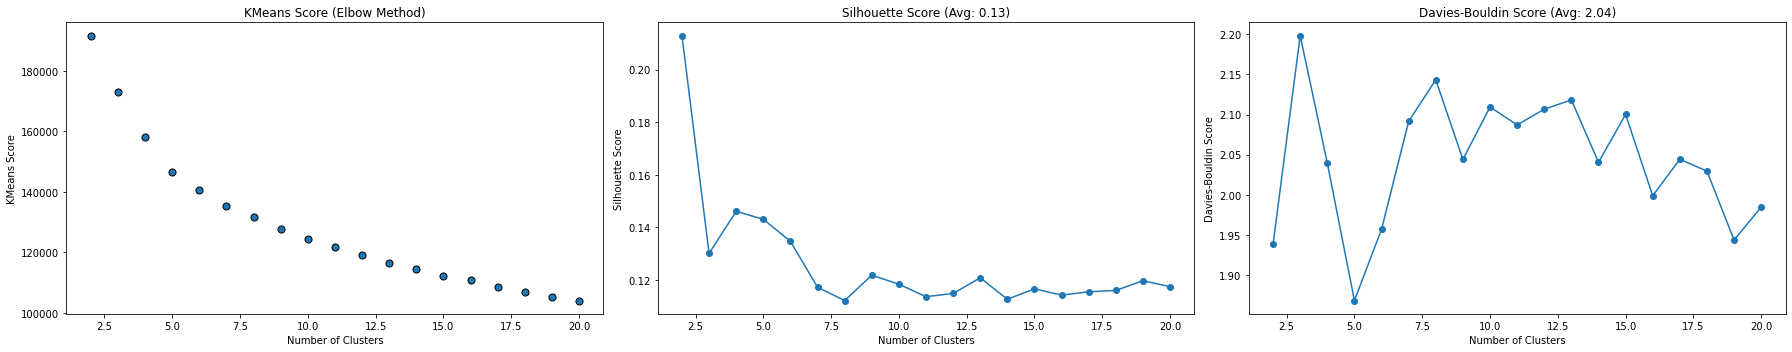

In [1374]:
# Выбираем признаки для кластеризации
X = df[[
 'floor_count',
 'lat',
 'lon',
 'area',
 'area_kitchen',
 'floor',
 'house_type',
 'price_object',
 'rooms_count',
 'sanuzel_multiple',
 'type_flat',
 'renovation',
 'selling_type',
 'normalized_price',
 'year_build',
 'elevator']].values

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Пример использования:
km_scores, km_silhouette, db_score = evaluate_kmeans_clustering(X_scaled, max_clusters=20)

Evaluating KMeans clustering: 100%|██████████| 19/19 [01:08<00:00,  3.59s/it]


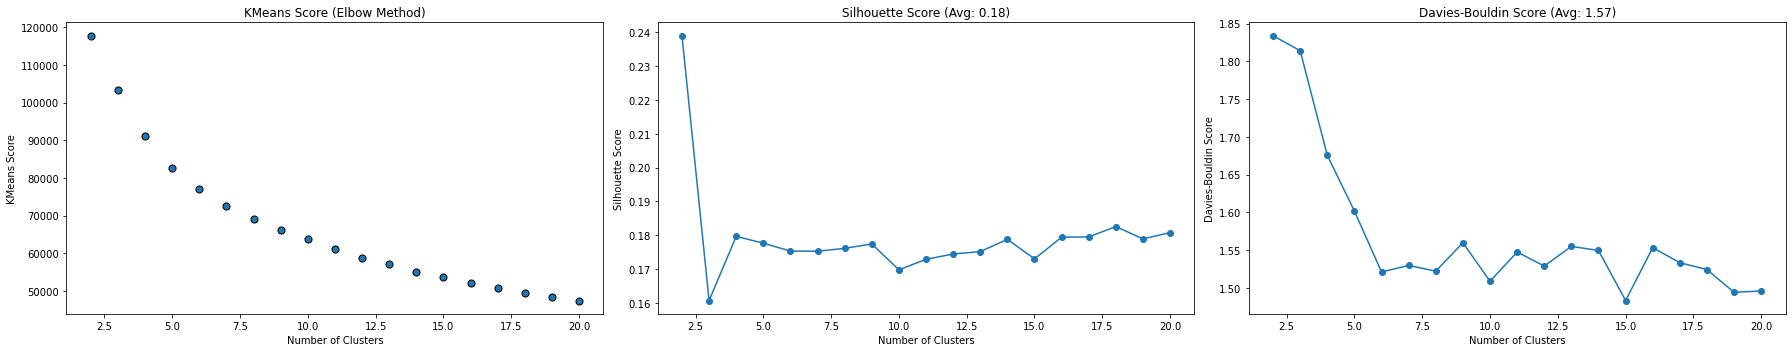

In [1375]:
# Выбираем признаки для кластеризации
X = df[[
#  'floor_count',
 'lat',
 'lon',
 'area',
#  'area_kitchen',
 'floor',
 'house_type',
 'price_object',
 'rooms_count',
#  'sanuzel_multiple',
 'type_flat',
#  'renovation',
#  'selling_type',
 'normalized_price',
 'year_build',
#  'elevator'
]].values

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Пример использования:
km_scores, km_silhouette, db_score = evaluate_kmeans_clustering(X_scaled, max_clusters=20)

Evaluating KMeans clustering: 100%|██████████| 19/19 [01:11<00:00,  3.78s/it]


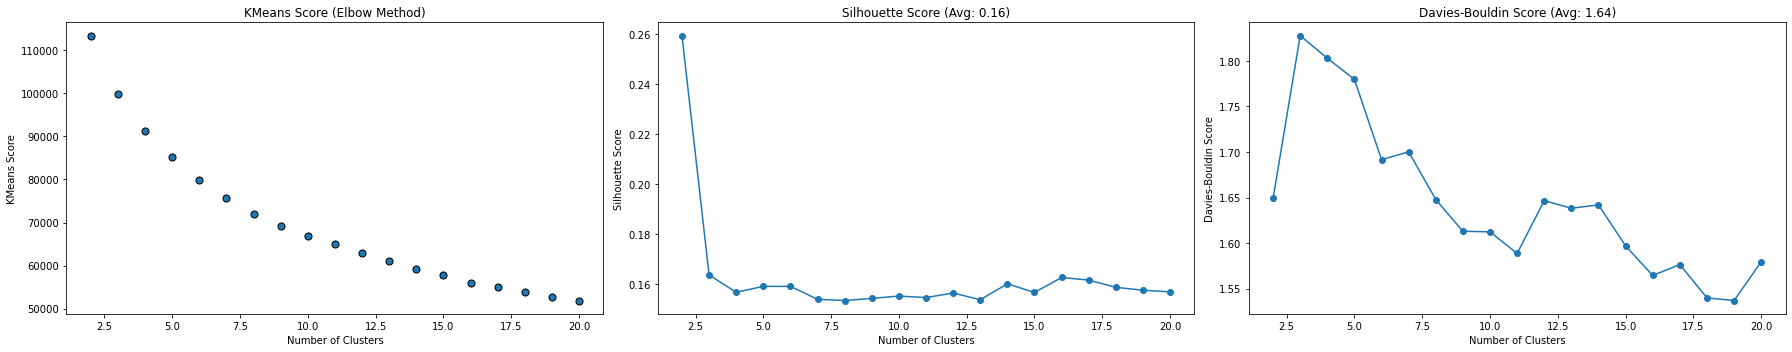

In [1387]:
# Выбираем признаки для кластеризации
X = df[[
 'floor_count',
 'lat',
 'lon',
 'area',
 'area_kitchen',
 'floor',
 'house_type',
#  'price_object',
 'rooms_count',
#  'sanuzel_multiple',
#  'type_flat',
#  'renovation',
#  'selling_type',
 'normalized_price',
 'year_build',
#  'elevator'
]].values

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Пример использования:
km_scores, km_silhouette, db_score = evaluate_kmeans_clustering(X_scaled, max_clusters=20)

In [1388]:
# Кластеризация с оптимальным числом кластеров
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
df_no_code['cluster3'] = kmeans.labels_

for cluster_label in df_no_code['cluster3'].unique():
    cluster_data = df_no_code[df_no_code['cluster3'] == cluster_label]
    print(f"Кластер {cluster_label}:")
    print(f"  Средняя цена за кв.м: {round(cluster_data['normalized_price'].mean(), 2)}")
    print(f"  Средняя площадь: {round(cluster_data['area'].mean(), 2)}")
    print(f"  Количество объектов: {len(cluster_data)}")

Кластер 2:
  Средняя цена за кв.м: 183824.62
  Средняя площадь: 53.93
  Количество объектов: 4008
Кластер 0:
  Средняя цена за кв.м: 123062.09
  Средняя площадь: 57.08
  Количество объектов: 4984
Кластер 1:
  Средняя цена за кв.м: 135117.68
  Средняя площадь: 34.7
  Количество объектов: 5824


In [1392]:
# Кластеризация с оптимальным числом кластеров
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
df_no_code['cluster4'] = kmeans.labels_

for cluster_label in df_no_code['cluster4'].unique():
    cluster_data = df_no_code[df_no_code['cluster4'] == cluster_label]
    print(f"Кластер {cluster_label}:")
    print(f"  Средняя цена за кв.м: {round(cluster_data['normalized_price'].mean(), 2)}")
    print(f"  Средняя площадь: {round(cluster_data['area'].mean(), 2)}")
    print(f"  Количество объектов: {len(cluster_data)}")
    print(f"  Количество уникальных: {cluster_data.house_type.unique()}")

Кластер 0:
  Средняя цена за кв.м: 183874.98
  Средняя площадь: 60.38
  Количество объектов: 2942
  Количество уникальных: ['Кирпичный' 'Монолитный' 'Блочный' 'Панельный' 'Монолитно-кирпичный']
Кластер 3:
  Средняя цена за кв.м: 122728.03
  Средняя площадь: 57.25
  Количество объектов: 4569
  Количество уникальных: ['Панельный' 'Кирпичный' 'Монолитно-кирпичный' 'Монолитный' 'Блочный'
 'Деревянный']
Кластер 1:
  Средняя цена за кв.м: 124375.64
  Средняя площадь: 36.64
  Количество объектов: 4349
  Количество уникальных: ['Кирпичный' 'Деревянный' 'Блочный' 'Панельный' 'Монолитно-кирпичный'
 'Монолитный']
Кластер 2:
  Средняя цена за кв.м: 167260.39
  Средняя площадь: 35.25
  Количество объектов: 2956
  Количество уникальных: ['Панельный' 'Монолитно-кирпичный' 'Кирпичный' 'Блочный' 'Монолитный'
 'Деревянный']


In [1390]:
# Кластеризация с оптимальным числом кластеров
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)
df_no_code['cluster5'] = kmeans.labels_

for cluster_label in df_no_code['cluster5'].unique():
    cluster_data = df_no_code[df_no_code['cluster5'] == cluster_label]
    print(f"Кластер {cluster_label}:")
    print(f"  Средняя цена за кв.м: {round(cluster_data['normalized_price'].mean(), 2)}")
    print(f"  Средняя площадь: {round(cluster_data['area'].mean(), 2)}")
    print(f"  Количество объектов: {len(cluster_data)}")

Кластер 2:
  Средняя цена за кв.м: 180243.41
  Средняя площадь: 69.57
  Количество объектов: 2027
Кластер 0:
  Средняя цена за кв.м: 122887.3
  Средняя площадь: 58.17
  Количество объектов: 3831
Кластер 4:
  Средняя цена за кв.м: 127636.76
  Средняя площадь: 36.09
  Количество объектов: 4235
Кластер 3:
  Средняя цена за кв.м: 184563.49
  Средняя площадь: 38.15
  Количество объектов: 2629
Кластер 1:
  Средняя цена за кв.м: 131395.51
  Средняя площадь: 40.94
  Количество объектов: 2094
